In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
models = ['Price-only', 'Sentiment-only', 'Static Concat', 'Regime-Aware']

metrics_3h = {
    'Accuracy':  [0.4883, 0.5190, 0.5019, 0.5117],
    'Precision': [0.4991, 0.5162, 0.5172, 0.5200],
    'Recall':    [0.4044, 0.9067, 0.3778, 0.5778],
    'F1':        [0.4468, 0.6579, 0.4366, 0.5474],
    'AUC':       [0.4968, 0.4938, 0.4939, 0.5084],
}

metrics_6h = {
    'Accuracy':  [0.4852, 0.5123, 0.5284, 0.4837],
    'Precision': [0.5339, 0.5271, 0.5316, 0.5036],
    'Recall':    [0.0916, 0.6501, 0.6489, 0.6090],
    'F1':        [0.1563, 0.5822, 0.5844, 0.5513],
    'AUC':       [0.5210, 0.5170, 0.5253, 0.4902],
}

ablation_labels = ['Full Model', 'No Sentiment', 'No Regime Gate', 'No Fusion Weight']

ablation_3h = {
    'Accuracy':  [0.5117, 0.4580, 0.5011, 0.4966],
    'Precision': [0.5200, 0.4666, 0.5076, 0.5048],
    'Recall':    [0.5778, 0.4237, 0.7896, 0.7822],
    'F1':        [0.5474, 0.4441, 0.6180, 0.6136],
    'AUC':       [0.5084, 0.4766, 0.4841, 0.4797],
}

ablation_6h = {
    'Accuracy':  [0.4837, 0.4875, 0.4739, 0.4777],
    'Precision': [0.5036, 0.5188, 0.4916, 0.4914],
    'Recall':    [0.6090, 0.2209, 0.2965, 0.0828],
    'F1':        [0.5513, 0.3099, 0.3699, 0.1418],
    'AUC':       [0.4902, 0.4721, 0.4799, 0.4608],
}

In [3]:
COLORS     = ['#2D2D2D', '#6B7280', '#F7931A', '#0F3460']
ABL_COLORS = ['#0F3460', '#F7931A', '#6B7280', '#2D2D2D']
ACCENT     = '#F7931A'
BG         = '#FAFAFA'
SAVEPATH   = 'C:\\Users\\Abdullah\\Desktop\\Code\\Sentiment Based Stock\\Sentiment Based Stocks\\figures\\'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'figure.facecolor':  BG,
    'axes.facecolor':    BG,
})

def save(name):
    plt.savefig(SAVEPATH + name, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved: {name}")

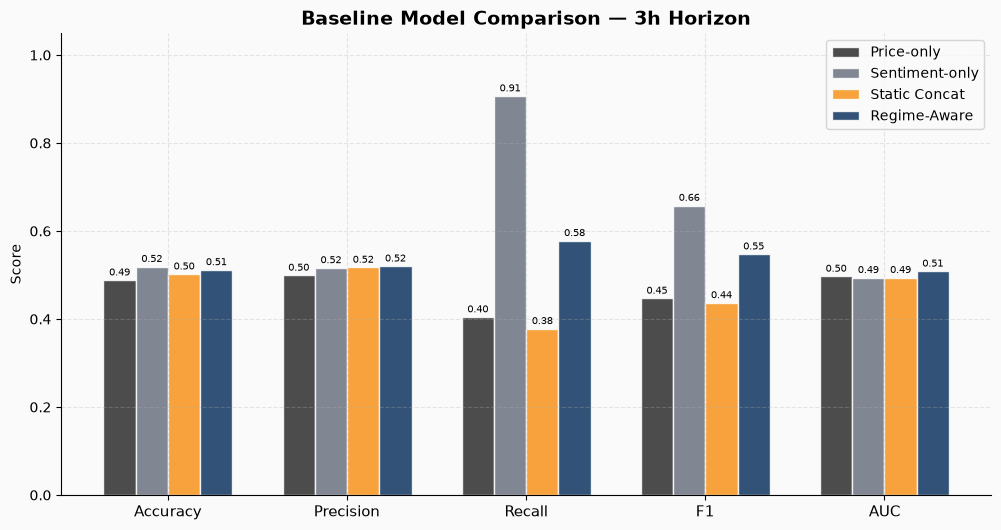

Saved: fig1_baseline_3h.png


In [5]:
metric_names = list(metrics_3h.keys())
x     = np.arange(len(metric_names))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 6))
for i, (model, color) in enumerate(zip(models, COLORS)):
    vals = [metrics_3h[m][i] for m in metric_names]
    bars = ax.bar(x + i * width, vals, width, label=model,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Baseline Model Comparison — 3h Horizon', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(fontsize=10)
save('fig1_baseline_3h.png')

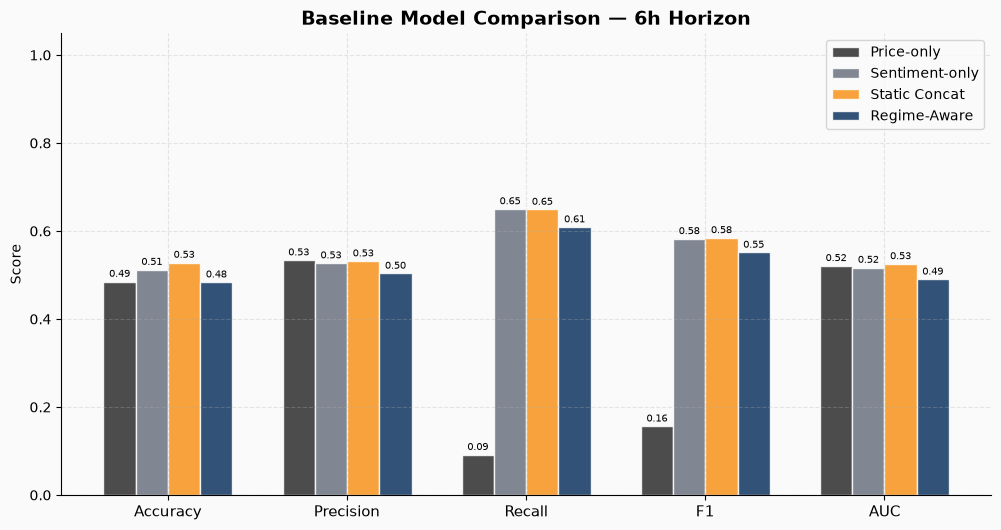

Saved: fig2_baseline_6h.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
for i, (model, color) in enumerate(zip(models, COLORS)):
    vals = [metrics_6h[m][i] for m in metric_names]
    bars = ax.bar(x + i * width, vals, width, label=model,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Baseline Model Comparison — 6h Horizon', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(fontsize=10)
save('fig2_baseline_6h.png')

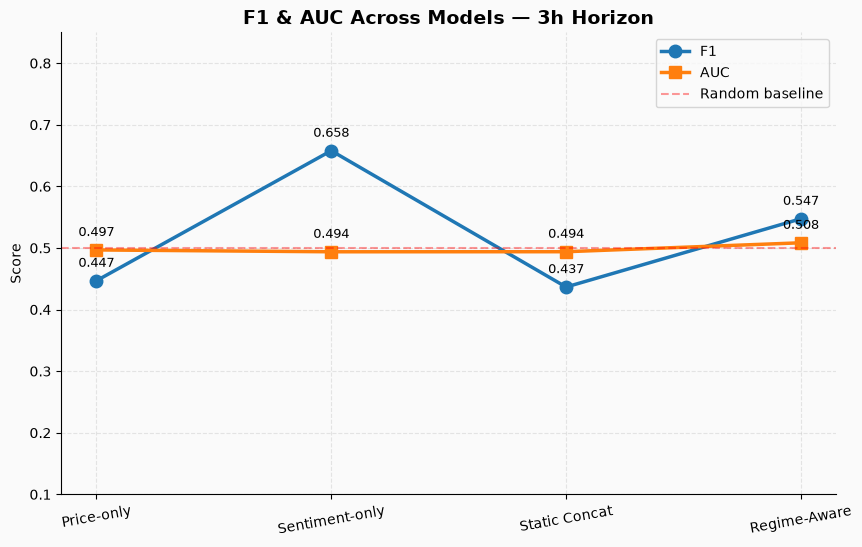

Saved: fig3_f1_auc_3h.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for metric, marker in [('F1', 'o'), ('AUC', 's')]:
    vals = metrics_3h[metric]
    ax.plot(models, vals, marker=marker, linewidth=2.5,
            label=metric, markersize=9)
    for i, v in enumerate(vals):
        ax.annotate(f'{v:.3f}', (models[i], v),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=9)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='Random baseline')
ax.set_ylim(0.1, 0.85)
ax.set_title('F1 & AUC Across Models — 3h Horizon', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=10)
save('fig3_f1_auc_3h.png')

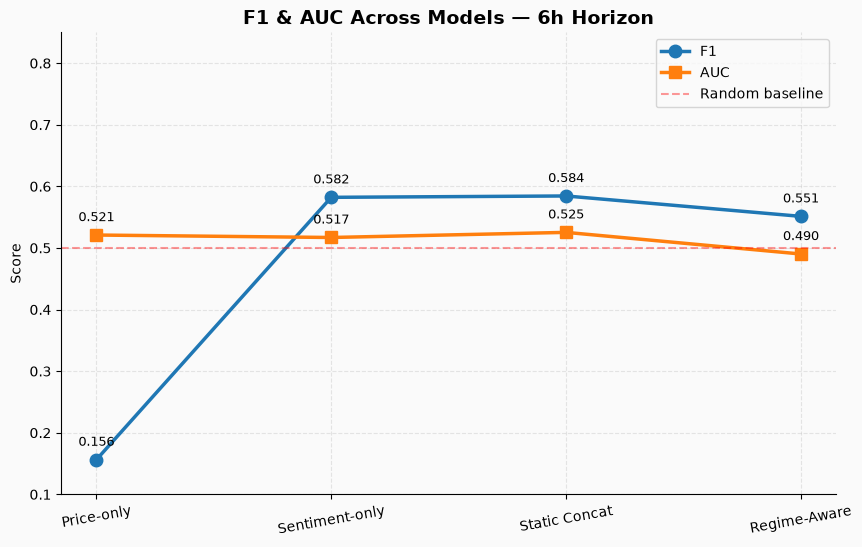

Saved: fig4_f1_auc_6h.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
for metric, marker in [('F1', 'o'), ('AUC', 's')]:
    vals = metrics_6h[metric]
    ax.plot(models, vals, marker=marker, linewidth=2.5,
            label=metric, markersize=9)
    for i, v in enumerate(vals):
        ax.annotate(f'{v:.3f}', (models[i], v),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=9)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='Random baseline')
ax.set_ylim(0.1, 0.85)
ax.set_title('F1 & AUC Across Models — 6h Horizon', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=10)
save('fig4_f1_auc_6h.png')

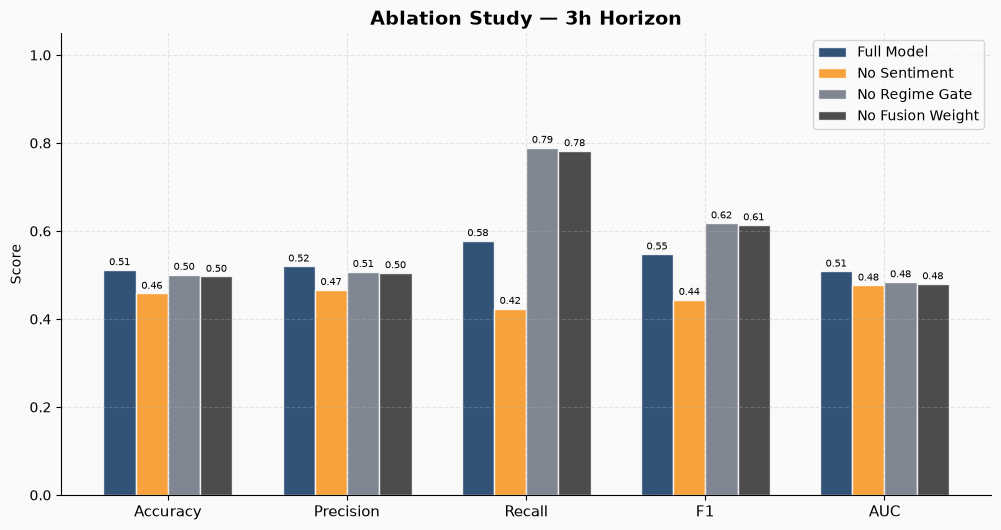

Saved: fig5_ablation_3h.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
x2 = np.arange(len(metric_names))
for i, (label, color) in enumerate(zip(ablation_labels, ABL_COLORS)):
    vals = [ablation_3h[m][i] for m in metric_names]
    bars = ax.bar(x2 + i * width, vals, width, label=label,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x2 + width * 1.5)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Ablation Study — 3h Horizon', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(fontsize=10)
save('fig5_ablation_3h.png')

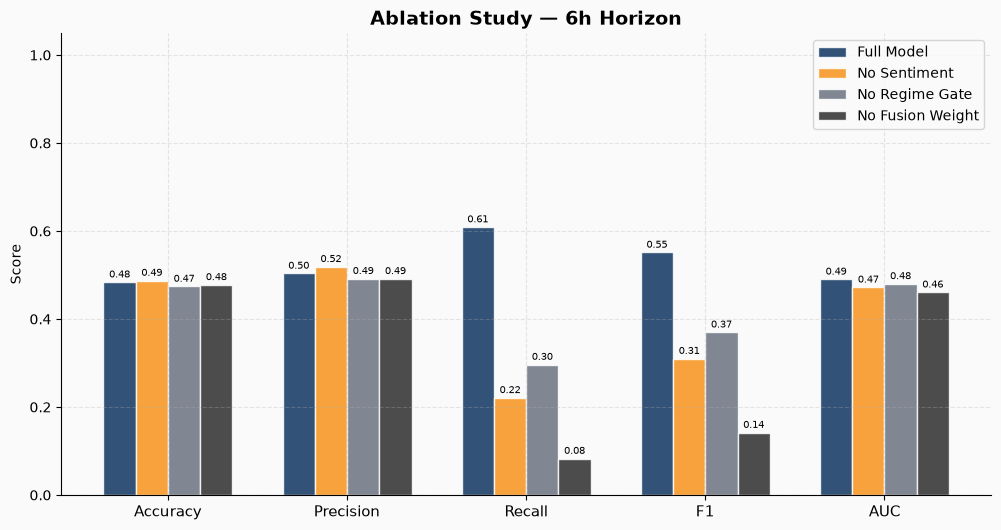

Saved: fig6_ablation_6h.png


In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
for i, (label, color) in enumerate(zip(ablation_labels, ABL_COLORS)):
    vals = [ablation_6h[m][i] for m in metric_names]
    bars = ax.bar(x2 + i * width, vals, width, label=label,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x2 + width * 1.5)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Ablation Study — 6h Horizon', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(fontsize=10)
save('fig6_ablation_6h.png')

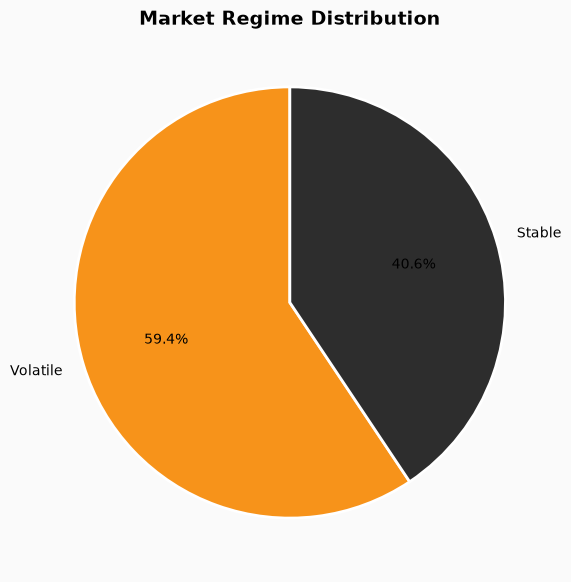

Saved: fig7_regime_distribution.png


In [12]:
df = pd.read_csv('C:\\Users\\Abdullah\\Desktop\\Code\\Sentiment Based Stock\\Sentiment Based Stocks\\results\\final_dataset_labeled.csv')
regime_counts = df['regime'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(regime_counts.values,
       labels=['Volatile', 'Stable'],
       colors=[ACCENT, '#2D2D2D'],
       autopct='%1.1f%%',
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Market Regime Distribution', fontsize=14, fontweight='bold')

plt.savefig('C:\\Users\\Abdullah\\Desktop\\Code\\Sentiment Based Stock\\Sentiment Based Stocks\\figures\\fig7_regime_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: fig7_regime_distribution.png")

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv('C:\\Users\\Abdullah\\Desktop\\Code\\Sentiment Based Stock\\Sentiment Based Stocks\\results\\final_dataset_labeled.csv')
df['hour'] = pd.to_datetime(df['hour'])

SAVEPATH = 'C:\\Users\\Abdullah\\Desktop\\Code\\Sentiment Based Stock\\Sentiment Based Stocks\\figures\\'
ACCENT   = '#F7931A'
DARK     = '#0F3460'
BG       = '#FAFAFA'

In [14]:
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.facecolor':  BG,
    'axes.facecolor':    BG,
})

def save(name):
    plt.savefig(SAVEPATH + name, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved: {name}")


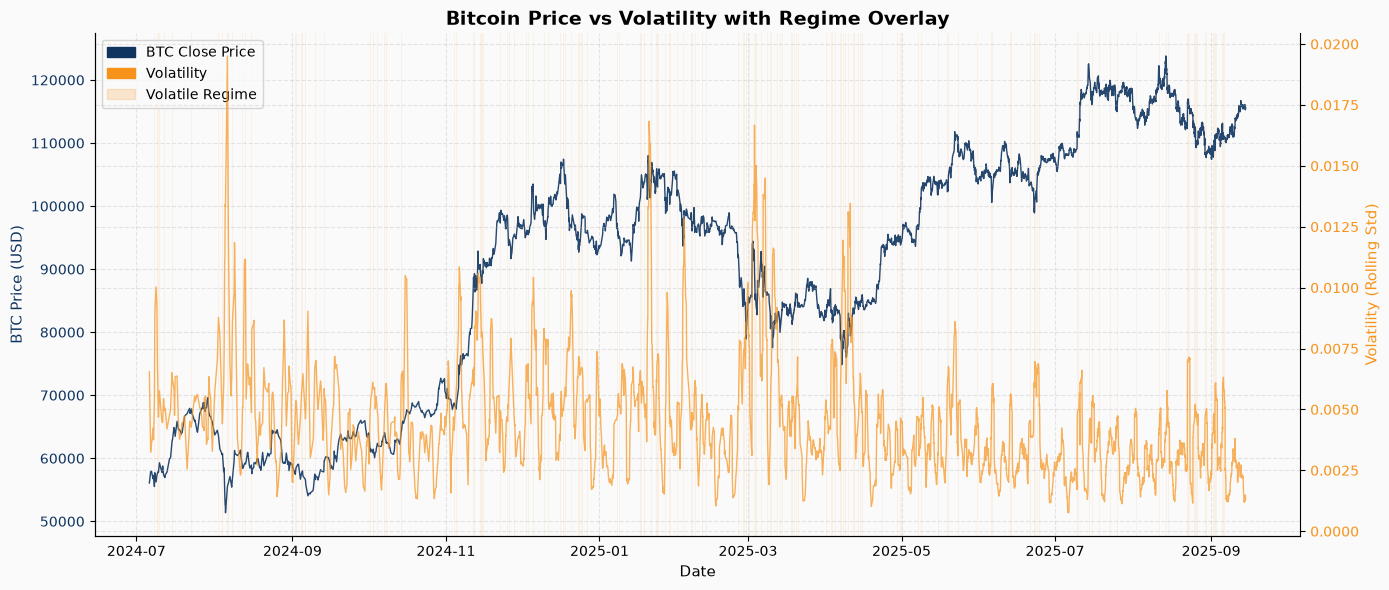

Saved: fig8_regime_vs_price.png


In [15]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df['hour'], df['close'], color=DARK, linewidth=1, label='BTC Close Price', alpha=0.9)
ax1.set_ylabel('BTC Price (USD)', fontsize=11, color=DARK)
ax1.tick_params(axis='y', labelcolor=DARK)
ax1.set_xlabel('Date', fontsize=11)

volatile = df[df['regime'] == 1]
for _, row in df.iterrows():
    if row['regime'] == 1:
        ax1.axvspan(row['hour'], row['hour'] + pd.Timedelta(hours=1),
                    alpha=0.08, color=ACCENT, linewidth=0)

ax2 = ax1.twinx()
ax2.plot(df['hour'], df['volatility'], color=ACCENT, linewidth=1,
         label='Volatility', alpha=0.7)
ax2.set_ylabel('Volatility (Rolling Std)', fontsize=11, color=ACCENT)
ax2.tick_params(axis='y', labelcolor=ACCENT)
ax2.spines['right'].set_visible(True)
ax2.spines['top'].set_visible(False)

patch1 = mpatches.Patch(color=DARK,   label='BTC Close Price')
patch2 = mpatches.Patch(color=ACCENT, label='Volatility')
patch3 = mpatches.Patch(color=ACCENT, alpha=0.2, label='Volatile Regime')
ax1.legend(handles=[patch1, patch2, patch3], fontsize=10, loc='upper left')

plt.title('Bitcoin Price vs Volatility with Regime Overlay', fontsize=14, fontweight='bold')
plt.tight_layout()
save('fig8_regime_vs_price.png')

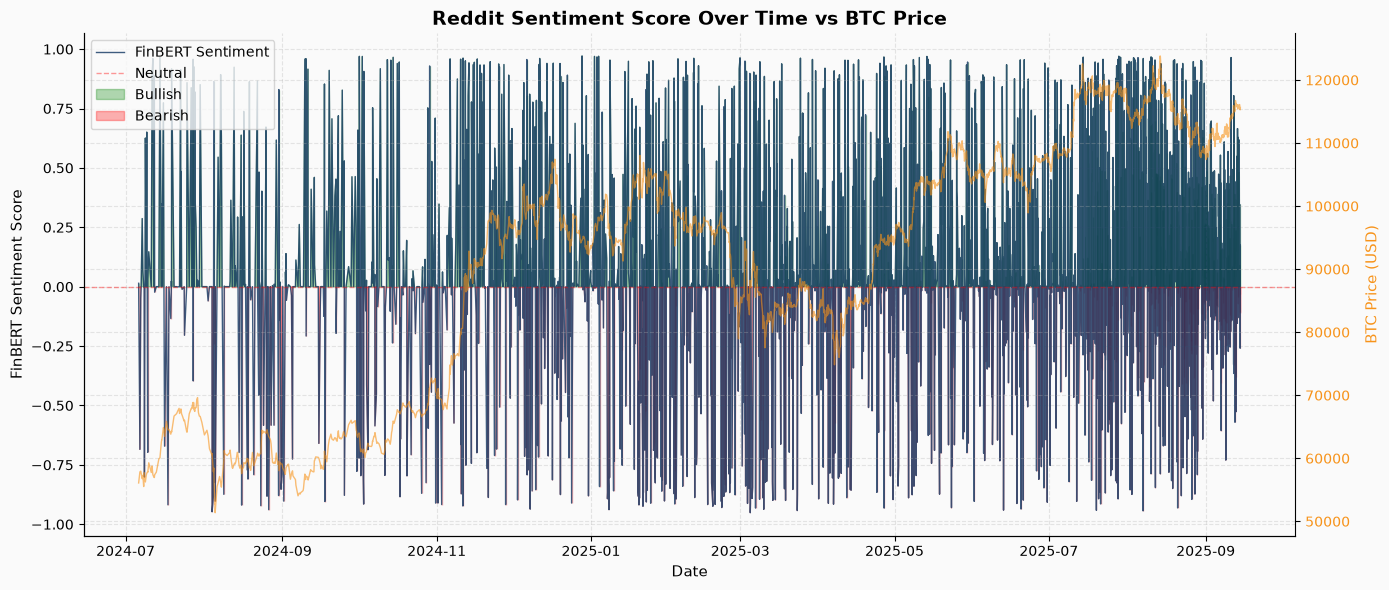

Saved: fig9_sentiment_over_time.png


In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['hour'], df['mean_finbert'], color=DARK, linewidth=1,
        label='FinBERT Sentiment', alpha=0.8)
ax.axhline(0, color='red', linestyle='--', alpha=0.4, linewidth=1, label='Neutral')
ax.fill_between(df['hour'], df['mean_finbert'], 0,
                where=df['mean_finbert'] > 0,
                alpha=0.3, color='green', label='Bullish')
ax.fill_between(df['hour'], df['mean_finbert'], 0,
                where=df['mean_finbert'] < 0,
                alpha=0.3, color='red', label='Bearish')

ax2 = ax.twinx()
ax2.plot(df['hour'], df['close'], color=ACCENT, linewidth=1,
         alpha=0.6, label='BTC Price')
ax2.set_ylabel('BTC Price (USD)', fontsize=11, color=ACCENT)
ax2.tick_params(axis='y', labelcolor=ACCENT)
ax2.spines['right'].set_visible(True)
ax2.spines['top'].set_visible(False)

ax.set_ylabel('FinBERT Sentiment Score', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
plt.title('Reddit Sentiment Score Over Time vs BTC Price', fontsize=14, fontweight='bold')
plt.tight_layout()
save('fig9_sentiment_over_time.png')

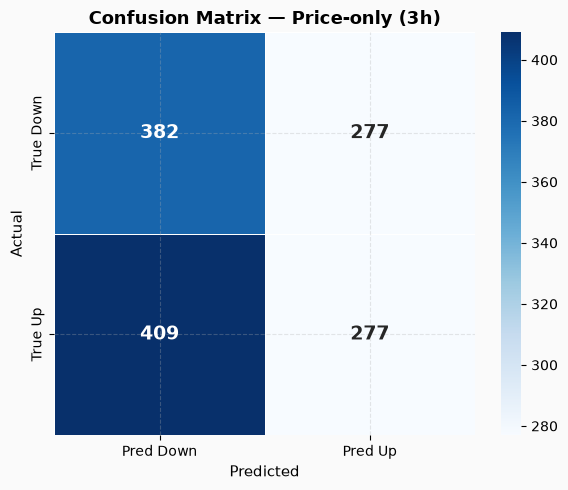

Saved: fig10_cm_Price-only_3h.png


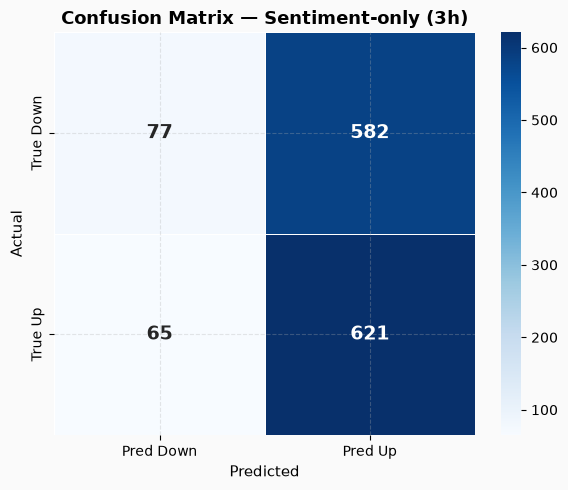

Saved: fig10_cm_Sentiment-only_3h.png


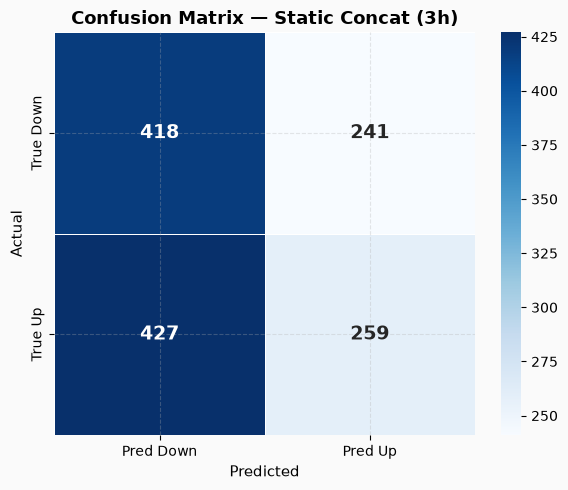

Saved: fig10_cm_Static_Concat_3h.png


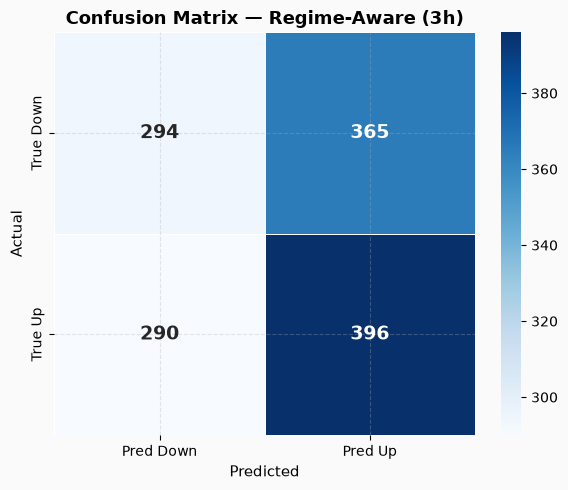

Saved: fig10_cm_Regime-Aware_3h.png


In [17]:
results = {
    'Price-only\n(3h)':       {'y_true': [1]*696 + [0]*625,  'y_pred': [1]*282 + [0]*414 + [1]*218 + [0]*407},
    'Sentiment-only\n(3h)':   {'y_true': [1]*696 + [0]*625,  'y_pred': [1]*631 + [0]*65  + [1]*562 + [0]*63},
    'Static Concat\n(3h)':    {'y_true': [1]*696 + [0]*625,  'y_pred': [1]*263 + [0]*433 + [1]*236 + [0]*389},
    'Regime-Aware\n(3h)':     {'y_true': [1]*696 + [0]*625,  'y_pred': [1]*402 + [0]*294 + [1]*305 + [0]*320},
}

test_df = df[df['hour'] >= '2025-07-01']
y_true_3h = test_df['label_3h'].values[24:]

def approx_cm(accuracy, precision, recall, n_pos, n_neg):
    tp = int(recall * n_pos)
    fp = int(tp / precision - tp) if precision > 0 else 0
    fn = n_pos - tp
    tn = n_neg - fp
    return np.array([[tn, fp], [fn, tp]])

n_pos = int(test_df['label_3h'].sum())
n_neg = len(test_df) - n_pos

cms = {
    'Price-only (3h)':      approx_cm(0.4883, 0.4991, 0.4044, n_pos, n_neg),
    'Sentiment-only (3h)':  approx_cm(0.5190, 0.5162, 0.9067, n_pos, n_neg),
    'Static Concat (3h)':   approx_cm(0.5019, 0.5172, 0.3778, n_pos, n_neg),
    'Regime-Aware (3h)':    approx_cm(0.5117, 0.5200, 0.5778, n_pos, n_neg),
}

for name, cm in cms.items():
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Down', 'Pred Up'],
                yticklabels=['True Down', 'True Up'],
                ax=ax, linewidths=0.5, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)
    plt.tight_layout()
    fname = 'fig10_cm_' + name.replace('\n','').replace(' ','_').replace('(','').replace(')','') + '.png'
    save(fname)

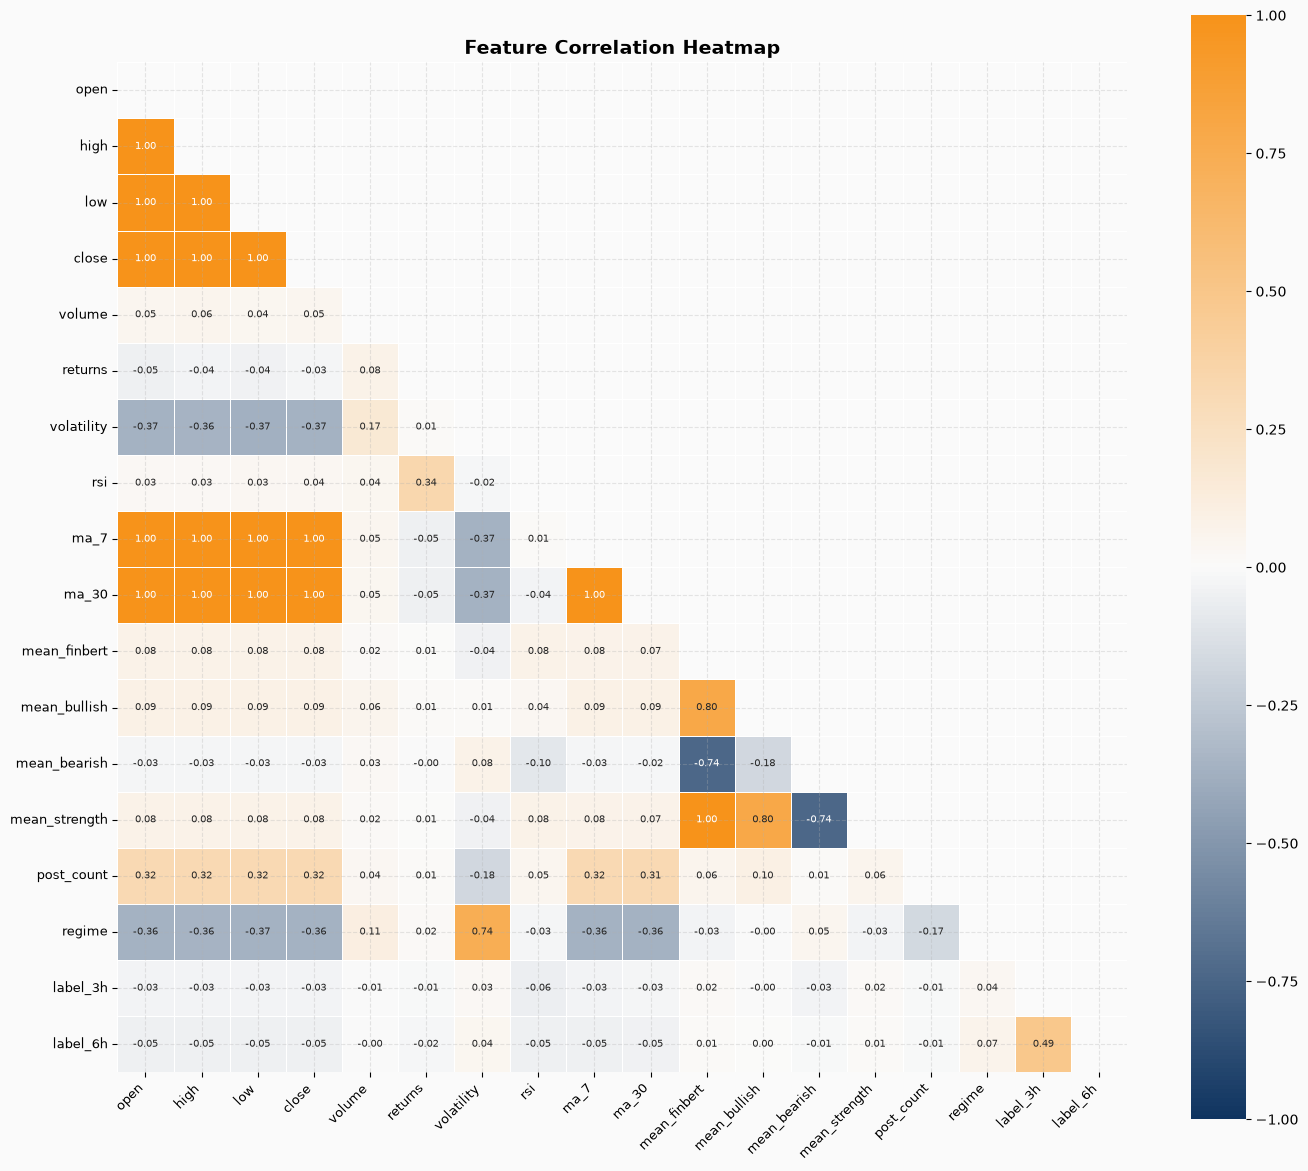

Saved: fig11_correlation_heatmap.png


In [18]:
feature_cols = ['open', 'high', 'low', 'close', 'volume',
                'returns', 'volatility', 'rsi', 'ma_7', 'ma_30',
                'mean_finbert', 'mean_bullish', 'mean_bearish',
                'mean_strength', 'post_count', 'regime',
                'label_3h', 'label_6h']

corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = LinearSegmentedColormap.from_list('btc', ['#0F3460', '#FAFAFA', '#F7931A'])
sns.heatmap(corr, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.4, linecolor='white',
            square=True, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
save('fig11_correlation_heatmap.png')

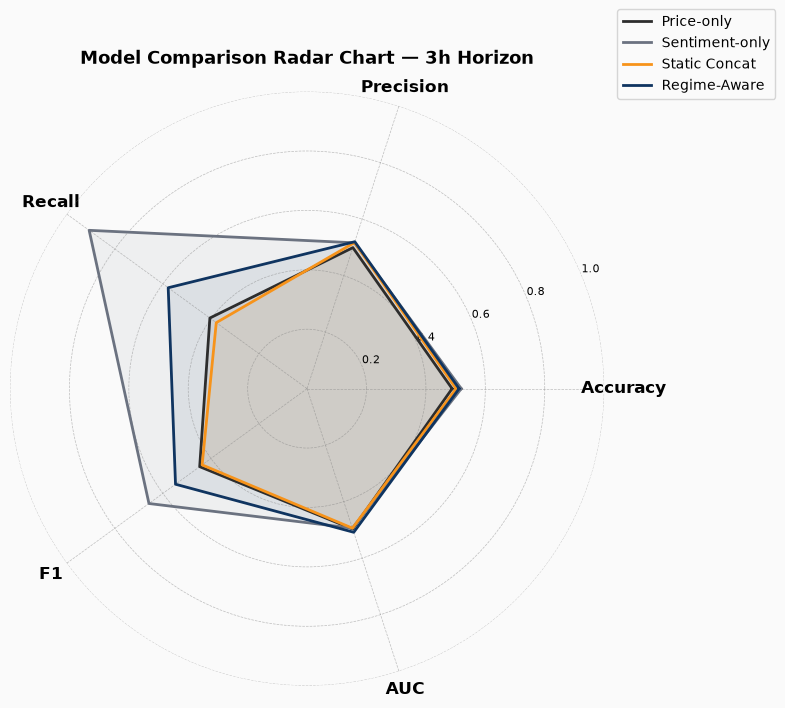

Saved: fig12_radar_chart.png

All additional figures saved.


In [19]:
categories  = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
model_names = ['Price-only', 'Sentiment-only', 'Static Concat', 'Regime-Aware']
colors      = ['#2D2D2D', '#6B7280', '#F7931A', '#0F3460']

values_3h = [
    [0.4883, 0.4991, 0.4044, 0.4468, 0.4968],
    [0.5190, 0.5162, 0.9067, 0.6579, 0.4938],
    [0.5019, 0.5172, 0.3778, 0.4366, 0.4939],
    [0.5117, 0.5200, 0.5778, 0.5474, 0.5084],
]

N    = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor(BG)
fig.patch.set_facecolor(BG)

for vals, name, color in zip(values_3h, model_names, colors):
    vals_plot = vals + vals[:1]
    ax.plot(angles, vals_plot, linewidth=2, color=color, label=name)
    ax.fill(angles, vals_plot, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
ax.spines['polar'].set_visible(False)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=10)
ax.set_title('Model Comparison Radar Chart — 3h Horizon',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
save('fig12_radar_chart.png')

print("\nAll additional figures saved.")